$$
\providecommand{\bm}{\boldsymbol}
\providecommand{\R}{\mathbb{R}}
\providecommand{\xv}{\mathbf{x}}
\providecommand{\E}{\mathbb{E}}
\providecommand{\fh}{\hat{f}}
\providecommand{\sh}{\hat{s}}
\providecommand{\fmin}{f_{\min}}
\providecommand{\Dt}{\mathcal{D}^{[t]}}
$$

INSERT_problem_1

**Solution.**

INSERT_solution_1_text

INSERT_problem_2

INSERT_solution_2_pseudo

BO best after 10 evals: x = 0.7898, f = -1.5766


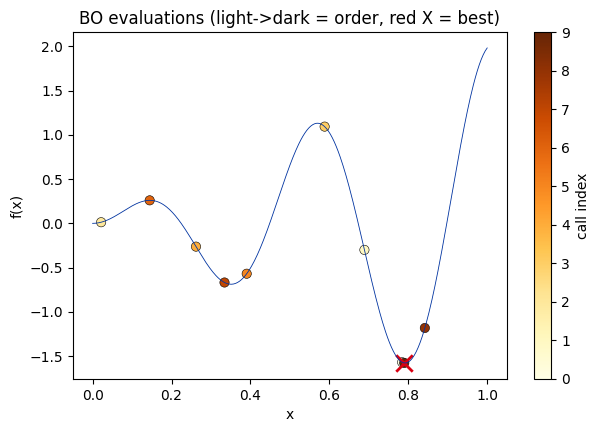

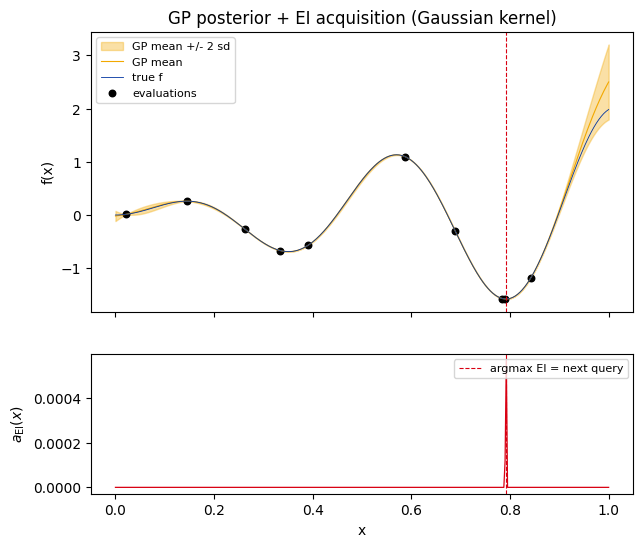

In [1]:
#| label: bo_loop
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize_scalar
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, RBF


def f(x):
    """Objective: 2x sin(14x) on [0, 1]."""
    return 2 * x * np.sin(14 * x)


# Gaussian-kernel GP surrogate, matching R's DiceKriging covtype = "gauss".
kernel = ConstantKernel(1.0) * RBF(length_scale=0.1)


def fit_gp(xd, yd):
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-8, normalize_y=True)
    gp.fit(xd[:, None], yd)
    return gp


# Expected improvement using the closed form derived in problem 1.
def ei(x, current_fmin, gp):
    mu, sd = gp.predict(np.array([[x]]), return_std=True)
    mu, sd = mu[0], max(sd[0], 1e-9)
    diff = current_fmin - mu
    z = diff / sd
    return diff * norm.cdf(z) + sd * norm.pdf(z)


# Initial design: 4 random points in [0, 1]
np.random.seed(308)
x_design = np.random.uniform(size=4)
y_design = f(x_design)
t = 4

while t < 10:
    gp = fit_gp(x_design, y_design)
    fmin = y_design.min()
    res = minimize_scalar(lambda x: -ei(x, fmin, gp),
                          bounds=(0, 1), method="bounded")
    x_design = np.append(x_design, res.x)
    y_design = np.append(y_design, f(res.x))
    t += 1

best = int(np.argmin(y_design))
print(f"BO best after 10 evals: x = {x_design[best]:.4f}, "
      f"f = {y_design[best]:+.4f}")

# Objective with BO's evaluations (light -> dark = evaluation order)
x_grid = np.linspace(0, 1, 401)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(x_grid, f(x_grid), color="#0033A0", linewidth=0.6)
sc = ax.scatter(x_design, y_design, c=np.arange(len(x_design)), cmap="YlOrBr",
                s=45, edgecolor="k", linewidth=0.4)
ax.scatter(x_design[best], y_design[best], color="#D90012", marker="x",
           s=140, linewidths=2)
ax.set_xlabel("x"); ax.set_ylabel("f(x)")
fig.colorbar(sc, ax=ax, label="call index")
ax.set_title("BO evaluations (light->dark = order, red X = best)")
plt.show()

# GP posterior at the final iteration (mean +/- 2*sd over the grid)
final_gp = fit_gp(x_design, y_design)
mu, sd = final_gp.predict(x_grid[:, None], return_std=True)

# EI induced by that surrogate; BO would query its argmax next.
fmin = y_design.min()
sd_safe = np.maximum(sd, 1e-9)
z = (fmin - mu) / sd_safe
ei_grid = (fmin - mu) * norm.cdf(z) + sd_safe * norm.pdf(z)
x_ei_next = x_grid[int(np.argmax(ei_grid))]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6), sharex=True,
                               gridspec_kw={"height_ratios": [2, 1]})
ax1.fill_between(x_grid, mu - 2 * sd, mu + 2 * sd, color="#F2A800", alpha=0.35,
                 label="GP mean +/- 2 sd")
ax1.plot(x_grid, mu, color="#F2A800", linewidth=0.8, label="GP mean")
ax1.plot(x_grid, f(x_grid), color="#0033A0", linewidth=0.6, label="true f")
ax1.scatter(x_design, y_design, color="black", s=22, label="evaluations")
ax1.axvline(x_ei_next, linestyle="--", color="#D90012", linewidth=0.8)
ax1.set_ylabel("f(x)"); ax1.legend(loc="upper left", fontsize=8)
ax1.set_title("GP posterior + EI acquisition (Gaussian kernel)")
ax2.plot(x_grid, ei_grid, color="#D90012", linewidth=0.9)
ax2.axvline(x_ei_next, linestyle="--", color="#D90012", linewidth=0.8,
            label="argmax EI = next query")
ax2.set_xlabel("x"); ax2.set_ylabel(r"$a_{\mathrm{EI}}(x)$")
ax2.legend(loc="upper right", fontsize=8)
plt.show()